In [1]:
%pip install -q python-dotenv langchain-openai
# %pip show python-dotenv langchain-openai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: c:\studyhub\ai\langgraph-agent\langgraphvenv\Scripts\python.exe -m pip install --upgrade pip


### Langchain vs Langgraph

#### Langchain을 활용한 방법

In [4]:
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv()  # 기본: .env -> dotenv_path 매개변수를 활용하여 경로를 직접 불러올 수 도 있음

True

In [5]:
from langchain_openai import ChatOpenAI

query = '인프런에는 어떤 강의가 있나요?'

llm = ChatOpenAI(model='gpt-4o-mini')  # OPENAI_API_KEY 환경변수로 설정되어 있다면, api_key 매개변수를 생략 가능
# llm = ChatOpenAI(model='gpt-4o-mini', api_key='키 이름')

llm.invoke(query)

AIMessage(content='인프런은 다양한 분야의 온라인 강의를 제공하는 플랫폼입니다. 일반적으로 다음과 같은 카테고리의 강의를 찾아볼 수 있습니다:\n\n1. **프로그래밍**: Python, Java, JavaScript, C++, Ruby 등 여러 프로그래밍 언어에 대한 강의.\n2. **웹 개발**: HTML, CSS, React, Vue.js, Node.js 등 웹 기술 관련 강의.\n3. **모바일 개발**: Android, iOS, Flutter, React Native 등 모바일 앱 개발 강의.\n4. **데이터 과학**: 데이터 분석, 머신러닝, 딥러닝, TensorFlow, Pandas 등 관련 기술.\n5. **경영 및 마케팅**: 디지털 마케팅, 스타트업 운영, 비즈니스 모델 설계 등의 강의.\n6. **디자인**: UX/UI 디자인, 그래픽 디자인, 포토샵, 일러스트레이터 강의.\n7. **클라우드와 DevOps**: AWS, Azure, Docker, Kubernetes 등을 다루는 강의.\n8. **시험 준비**: 자격증 취득을 위한 특화된 강의.\n\n각 강의는 강사의 소개, 커리큘럼, 수강 후기 등을 볼 수 있어 자신의 필요에 맞는 강의를 선택하기 좋습니다. 인프런 웹사이트를 방문하면 더 구체적인 정보와 최신 강의를 확인할 수 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 299, 'prompt_tokens': 18, 'total_tokens': 317, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached

#### Langgraph를 활용한 방법

In [6]:
# State, Node, Edge, Conditional Edge

# State : 현재 에이전트의 상태 <- 메시지, 문서 등등 state에 넣을 수 있다
# Node : 에이전트가 수행할 수 있는 작업, 행동, 기능 등등 <- 다른 에이전트가 될 수 있고, 함수가 될 수도 있다. 
# Edge : 노드와 노드를 연결하는 선, 노드 간의 "관계"를 나타냄 (실선) <- 노드 간의 "무조건적" 흐름, 의존성, 상호작용
# Conditional Edge : 조건부 엣지, 특정 조건이 충족될 때만 "선택적으로" 활성화되는 엣지 (점선) 


In [2]:
%pip install -q langgraph
# %pip show langgraph

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: c:\studyhub\ai\langgraph-agent\langgraphvenv\Scripts\python.exe -m pip install --upgrade pip


In [9]:
from typing import Annotated
from typing_extensions import TypedDict  
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage


class AgentState(TypedDict):  #  state는 Dict 형태 -> 딕셔너리로 값들을 관리.
    messages: list[Annotated[AnyMessage, add_messages]]  # List 형태 
    
    # AnyMessage란? System Message, HumanMessage, AIMessage 를 포함하는 클래스 -> 리스트 형태
    # add_messages라는 랭그래프 메서드를 활용해서 AnyMessage(System Message, HumanMessage, AIMessage) 값들이 messages 리스트에 추가된다. 

In [10]:
from langgraph.graph import StateGraph

# 그래프 빌더 생성
graph_builder = StateGraph(AgentState)  




In [11]:
# 노드 정의 : 작업 (엣지 전에 생성해야 함)
def generate(state: AgentState) -> AgentState:  # 노드이기 때문에 state를 인자로 받고, state를 return. 

    messages = state['messages']  # 현재 상태에서 메시지 가져오기
    ai_message = llm.invoke(messages)  # llm을 활용해서 메시지에 대한 응답 생성 
    return {"messages" : [ai_message]}  # messages가 list이기 때문에, ai_message를 리스트 형태로 반환.


In [12]:
# 엣지 추가 : 연결
# 모든 랭그래프는 스타트, 엔드를 가진다
from langgraph.graph import START, END

# 한번 추가되면 노드 이름은 고유해야 한다. -> 노드 이름이 중복되면 에러 발생
graph_builder.add_node('generate', generate)   # 노드를 먼저 추가 -> ()'노드 이름', '노드에서 수행할 작업 함수')

# 엣지 연결 : 스타트 노드에서 generate 노드로 연결, generate 노드에서 엔드 노드로 연결
graph_builder.add_edge(START, 'generate')  # 스타트 노드에서 generate 노드로 연결
graph_builder.add_edge('generate', END)  # generate 노드에서 엔드 노드로 연결

In [13]:
graph = graph_builder.compile()  # 그래프 빌드, 컴파일

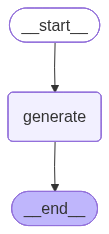

In [14]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))  # 그래프 시각화 (머메이드)

# 이렇게 해서 기본 Agent 가 생성된다. 이제 호출해야 함

In [15]:
# Agent 호출 : 그래프 실행
# invoke -> generate가 state 를 인자로 받으므로, state를 넣어서 invoke를 해야 함

from langchain_core.messages import HumanMessage

# 사용자의 질문이므로, HumanMessage의 형태로 query 전달. 
initial_state = {"messages": [HumanMessage(query)]}  # 초기 상태 정의 -> messages 리스트에 사용자 메시지 추가

graph.invoke(initial_state)  # 그래프 실행 -> generate 노드가 호출되고, llm이 응답을 생성하여 반환한다.

{'messages': [AIMessage(content='인프런은 다양한 주제의 온라인 강의를 제공하는 플랫폼입니다. 주로 IT, 프로그래밍, 데이터 사이언스, 웹 개발, 모바일 개발, 디자인, 마케팅, 비즈니스 등 다양한 분야의 강의가 있습니다. 예를 들어 아래와 같은 강의를 찾을 수 있습니다:\n\n1. **프로그래밍 언어**: Python, Java, JavaScript, C++, Ruby 등.\n2. **웹 개발**: HTML, CSS, React, Vue.js, Node.js 등.\n3. **데이터 사이언스**: 머신러닝, 데이터 분석, 인공지능 등.\n4. **모바일 개발**: 안드로이드, iOS 개발 등.\n5. **디자인**: UX/UI 디자인, 포토샵, 일러스트레이터 등.\n6. **마케팅**: 디지털 마케팅, SEO, 콘텐츠 마케팅 등.\n7. **비즈니스**: 프로젝트 관리, 스타트업, 경영 전략 등.\n\n각 강의는 주제별로 자세한 설명과 수강평이 포함되어 있어 학생들이 원하는 강의를 쉽게 선택할 수 있도록 돕습니다. 직접 인프런 웹사이트를 방문하면 현재 제공되고 있는 다양한 강의를 확인할 수 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 263, 'prompt_tokens': 18, 'total_tokens': 281, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', '

In [ ]:
# 간단한 프로젝트, 간단하게 랭체인으로 서비스를 만들 수 있느지를 한번 검증해보고, 
# 서비스를 확장하거나, 고도화하거나, 특정 워크플로우로 만들어야 한다면 그때 랭그래프를 활용해서 만드는 것도 좋은 방법이 될 수 있다. 
# 불필요하게 패키지 설치하는 것이 될 수 있음 (오버 엔지니어링의 가능성을 염두)